# Batch Isolation Forest screening across lattice specimens

This notebook discovers compatible per-strut feature tables, screens every specimen separately, and also fits a pooled model for comparison. Specimens without verified defect labels are evaluated as anomaly-screening experiments only; their flagged struts are not known true defects.

In [2]:
# Run once if these packages are not available in the selected kernel.
# %pip install -q scikit-learn pandas matplotlib

In [3]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
CONTAMINATION = 0.01

In [4]:
base = Path.cwd()
feature_dir = base / 'strut_feature_dataset' if (base / 'strut_feature_dataset').exists() else base
repo_dir = feature_dir.parent

expected_specimens = ['0-1', '0-2', '0-3', '0.5-1', '0.5-2', '0.5-3', '1-1', '1-2', '1-3']

# Add future per-specimen tables anywhere below strut_feature_dataset/specimens/.
# The current combined table is included automatically.
candidate_files = [feature_dir / 'strut_features_combined.csv']
candidate_files += sorted((feature_dir / 'specimens').glob('**/*.csv')) if (feature_dir / 'specimens').exists() else []
candidate_files = [p for p in dict.fromkeys(candidate_files) if p.exists()]

print('Feature tables discovered:')
for path in candidate_files:
    print(' -', path.resolve())

Feature tables discovered:
 - C:\Users\oconn\DSC2026\llnl_data_science_challenge_2026\strut_feature_dataset\strut_features_combined.csv


In [5]:
# Inventory raw files separately. A TIFF alone cannot produce strut-level predictions:
# it must first be registered to lattice geometry and converted into the same features.
raw_dir = repo_dir / 'data' / 'missing_struts'
tif_files = sorted((raw_dir / 'tif_stacks').glob('*.tif')) if (raw_dir / 'tif_stacks').exists() else []
json_files = sorted((raw_dir / 'registered_jsons').glob('*.json')) if (raw_dir / 'registered_jsons').exists() else []

inventory = pd.DataFrame({
    'expected_specimen': expected_specimens,
    'feature_table_available': False,
    'note': 'Requires registered geometry and per-strut CT feature extraction',
})
print(f'Raw TIFF stacks found: {len(tif_files)}')
print(f'Registered JSON files found: {len(json_files)}')

Raw TIFF stacks found: 1
Registered JSON files found: 1


In [6]:
tables = []
for path in candidate_files:
    table = pd.read_csv(path)
    if {'specimen_id', 'strut_id'}.issubset(table.columns):
        table['source_feature_table'] = str(path.resolve())
        tables.append(table)
    else:
        warnings.warn(f'Skipping {path.name}: specimen_id/strut_id columns are missing')

if not tables:
    raise FileNotFoundError('No compatible per-strut feature tables were found.')

df = pd.concat(tables, ignore_index=True, sort=False)
df = df.drop_duplicates(['specimen_id', 'strut_id'], keep='last')
available_specimens = sorted(df['specimen_id'].astype(str).unique())
inventory['feature_table_available'] = inventory['expected_specimen'].isin(available_specimens)
inventory.loc[inventory['feature_table_available'], 'note'] = 'Ready for Isolation Forest screening'

display(inventory)
print(f'Loaded {len(df):,} unique struts from {len(available_specimens)} specimen(s): {available_specimens}')

,expected_specimen,feature_table_available,note
0,0-1,False,Requires registered geometry and per-strut CT ...
1,0-2,False,Requires registered geometry and per-strut CT ...
2,0-3,False,Requires registered geometry and per-strut CT ...
3,0.5-1,True,Ready for Isolation Forest screening
4,0.5-2,False,Requires registered geometry and per-strut CT ...
5,0.5-3,False,Requires registered geometry and per-strut CT ...
6,1-1,False,Requires registered geometry and per-strut CT ...
7,1-2,False,Requires registered geometry and per-strut CT ...
8,1-3,False,Requires registered geometry and per-strut CT ...


Loaded 18,468 unique struts from 1 specimen(s): ['0.5-1']


In [7]:
# Use only columns that are available across the discovered tables.
# Existing defect scores/ranks/labels are excluded to avoid training on the comparison target.
preferred_features = [
    'ct_support_fraction', 'ct_longest_gap_fraction', 'ct_mean_local_max',
    'ct_min_local_max', 'ct_profile_min_to_mean', 'ct_continuity_score',
    'ct_local_baseline_intensity', 'ct_relative_local_intensity',
    'length_mm', 'nominal_diameter_mm', 'angle_to_build_z_deg',
    'minimum_endpoint_degree', 'mean_endpoint_degree',
    'minimum_midpoint_boundary_distance_mm', 'near_boundary_one_cell',
]
features = [name for name in preferred_features if name in df.columns and df[name].notna().any()]
if len(features) < 3:
    raise ValueError(f'Only {len(features)} usable features found. Run per-strut CT feature extraction first.')

print(f'Using {len(features)} features:')
print(features)

Using 15 features:
['ct_support_fraction', 'ct_longest_gap_fraction', 'ct_mean_local_max', 'ct_min_local_max', 'ct_profile_min_to_mean', 'ct_continuity_score', 'ct_local_baseline_intensity', 'ct_relative_local_intensity', 'length_mm', 'nominal_diameter_mm', 'angle_to_build_z_deg', 'minimum_endpoint_degree', 'mean_endpoint_degree', 'minimum_midpoint_boundary_distance_mm', 'near_boundary_one_cell']


In [8]:
def make_model(contamination=CONTAMINATION):
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', RobustScaler()),
        ('forest', IsolationForest(
            n_estimators=300,
            contamination=contamination,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

df['within_specimen_anomaly'] = False
df['within_specimen_anomaly_score'] = np.nan

for specimen, idx in df.groupby('specimen_id').groups.items():
    X_specimen = df.loc[idx, features]
    if len(X_specimen) < 100:
        warnings.warn(f'{specimen}: only {len(X_specimen)} rows; skipping within-specimen model')
        continue
    specimen_model = make_model()
    specimen_model.fit(X_specimen)
    df.loc[idx, 'within_specimen_anomaly'] = specimen_model.predict(X_specimen) == -1
    df.loc[idx, 'within_specimen_anomaly_score'] = -specimen_model.decision_function(X_specimen)

df.groupby('specimen_id')['within_specimen_anomaly'].agg(['count', 'sum', 'mean'])

,count,sum,mean
specimen_id,,,
0.5-1,18468,185,0.010017


In [9]:
# The pooled model can reveal between-specimen differences, but scanner/batch shifts may
# also cause flags. Compare it with the within-specimen result rather than using it alone.
pooled_model = make_model()
pooled_model.fit(df[features])
df['pooled_anomaly'] = pooled_model.predict(df[features]) == -1
df['pooled_anomaly_score'] = -pooled_model.decision_function(df[features])
df['two_model_consensus'] = df['within_specimen_anomaly'] & df['pooled_anomaly']

summary = df.groupby('specimen_id').agg(
    struts=('strut_id', 'size'),
    within_specimen_anomalies=('within_specimen_anomaly', 'sum'),
    pooled_anomalies=('pooled_anomaly', 'sum'),
    consensus_anomalies=('two_model_consensus', 'sum'),
    median_pooled_score=('pooled_anomaly_score', 'median'),
).reset_index()
display(summary)

,specimen_id,struts,within_specimen_anomalies,pooled_anomalies,consensus_anomalies,median_pooled_score
0,0.5-1,18468,185,185,185,-0.140041


In [10]:
# This is available only where an existing screening label exists. It is not
# independent ground truth because both approaches use related CT measurements.
if 'ct_severity_layer' in df.columns:
    evaluable = df['ct_severity_layer'].notna()
    existing = df['ct_severity_layer'].isin(['high', 'critical'])
    check = pd.crosstab(
        existing[evaluable].map({False: 'not high/critical', True: 'high/critical'}),
        df.loc[evaluable, 'two_model_consensus'].map({False: 'IF no', True: 'IF yes'}),
    )
    display(check)
else:
    print('No screening labels are present; anomaly candidates cannot be scored for accuracy.')

two_model_consensus,IF no,IF yes
ct_severity_layer,,
high/critical,44,48
not high/critical,18239,137


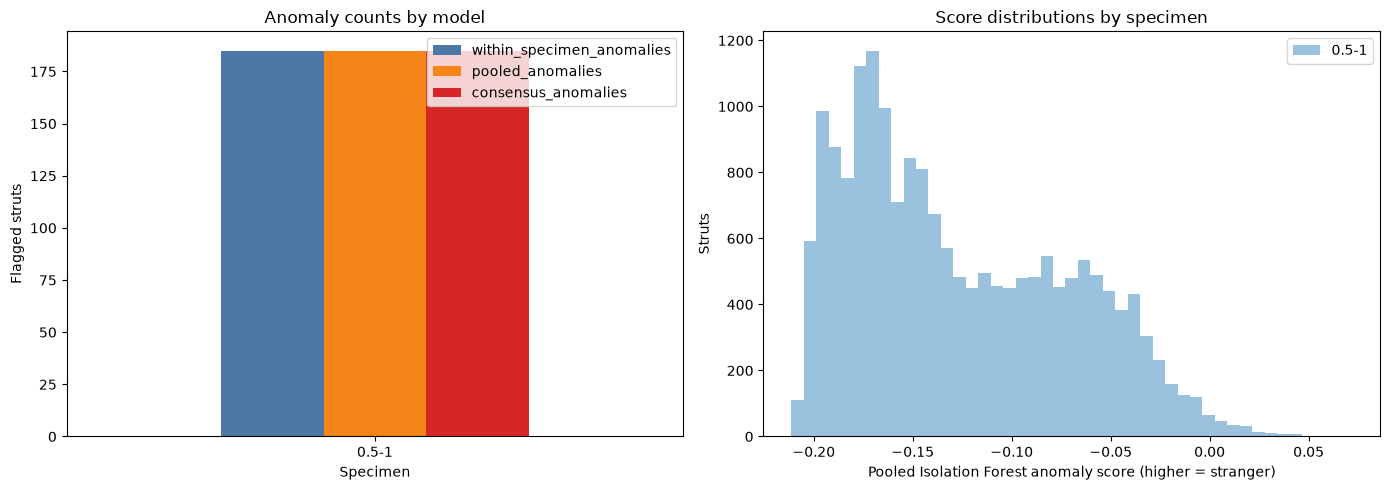

In [11]:
n_specimens = len(available_specimens)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary.plot(
    x='specimen_id',
    y=['within_specimen_anomalies', 'pooled_anomalies', 'consensus_anomalies'],
    kind='bar', ax=axes[0], color=['#4c78a8', '#f58518', '#d62728'],
)
axes[0].set(xlabel='Specimen', ylabel='Flagged struts', title='Anomaly counts by model')
axes[0].tick_params(axis='x', rotation=0)

for specimen, group in df.groupby('specimen_id'):
    axes[1].hist(group['pooled_anomaly_score'], bins=45, alpha=0.45, label=str(specimen))
axes[1].set(
    xlabel='Pooled Isolation Forest anomaly score (higher = stranger)',
    ylabel='Struts', title='Score distributions by specimen',
)
axes[1].legend()
fig.tight_layout()
plt.show()

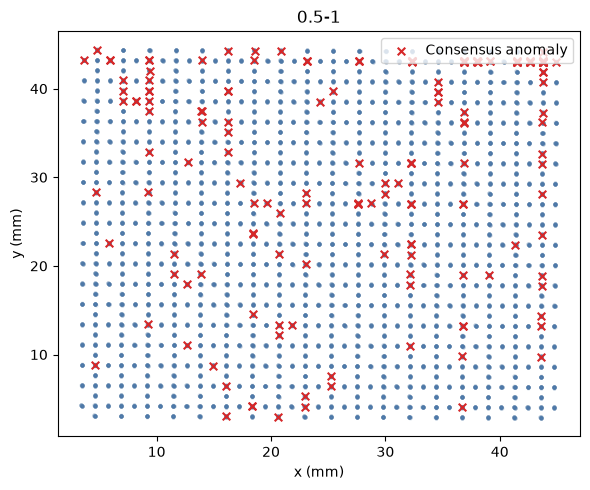

In [12]:
if {'midpoint_x_mm', 'midpoint_y_mm'}.issubset(df.columns):
    fig, axes = plt.subplots(1, n_specimens, figsize=(6 * n_specimens, 5), squeeze=False)
    for ax, (specimen, group) in zip(axes.flat, df.groupby('specimen_id')):
        normal = ~group['two_model_consensus']
        ax.scatter(group.loc[normal, 'midpoint_x_mm'], group.loc[normal, 'midpoint_y_mm'],
                   s=5, alpha=0.12, color='#4c78a8')
        ax.scatter(group.loc[~normal, 'midpoint_x_mm'], group.loc[~normal, 'midpoint_y_mm'],
                   s=30, marker='x', color='#d62728', label='Consensus anomaly')
        ax.set(title=str(specimen), xlabel='x (mm)', ylabel='y (mm)')
        ax.legend()
    fig.tight_layout()
    plt.show()

In [13]:
review_columns = [
    'specimen_id', 'strut_id', 'within_specimen_anomaly_score',
    'pooled_anomaly_score', 'within_specimen_anomaly', 'pooled_anomaly',
    'two_model_consensus',
]
review_columns += [c for c in ['ct_support_fraction', 'ct_relative_local_intensity',
                                'ct_continuity_score', 'ct_severity_layer'] if c in df.columns]
top_candidates = (
    df[review_columns]
      .sort_values(['specimen_id', 'pooled_anomaly_score'], ascending=[True, False])
      .groupby('specimen_id', group_keys=False)
      .head(20)
)
display(top_candidates)

,specimen_id,strut_id,within_specimen_anomaly_score,pooled_anomaly_score,within_specimen_anomaly,pooled_anomaly,two_model_consensus,ct_support_fraction,ct_relative_local_intensity,ct_continuity_score,ct_severity_layer
9273,0.5-1,9273,0.071880,0.071880,True,True,True,0.064516,0.677983,0.329587,high
13061,0.5-1,13061,0.071147,0.071147,True,True,True,0.032258,0.652077,0.304479,critical
9303,0.5-1,9303,0.064061,0.064061,True,True,True,0.096774,0.724027,0.358103,high
14637,0.5-1,14637,0.057225,0.057225,True,True,True,0.032258,0.647812,0.303176,critical
14625,0.5-1,14625,0.054070,0.054070,True,True,True,0.000000,0.615027,0.268116,critical
8823,0.5-1,8823,0.054045,0.054045,True,True,True,0.096774,0.665562,0.347173,critical
5223,0.5-1,5223,0.052464,0.052464,True,True,True,0.064516,0.710834,0.333193,high
8114,0.5-1,8114,0.047852,0.047852,True,True,True,0.064516,0.626367,0.324168,critical
14210,0.5-1,14210,0.044993,0.044993,True,True,True,0.032258,0.653639,0.301313,critical
12619,0.5-1,12619,0.044922,0.044922,True,True,True,0.000000,0.642873,0.280256,critical


In [14]:
output_dir = feature_dir / 'spatial_sequence_anomaly' / 'datasets'
output_dir.mkdir(parents=True, exist_ok=True)

result_columns = ['specimen_id', 'strut_id', 'within_specimen_anomaly',
                  'within_specimen_anomaly_score', 'pooled_anomaly',
                  'pooled_anomaly_score', 'two_model_consensus']
df[result_columns].to_csv(output_dir / 'batch_isolation_forest_results.csv', index=False)
summary.to_csv(output_dir / 'batch_isolation_forest_summary.csv', index=False)
inventory.to_csv(output_dir / 'batch_specimen_inventory.csv', index=False)

print('Saved:')
print((output_dir / 'batch_isolation_forest_results.csv').resolve())
print((output_dir / 'batch_isolation_forest_summary.csv').resolve())
print((output_dir / 'batch_specimen_inventory.csv').resolve())

Saved:
C:\Users\oconn\DSC2026\llnl_data_science_challenge_2026\strut_feature_dataset\spatial_sequence_anomaly\datasets\batch_isolation_forest_results.csv
C:\Users\oconn\DSC2026\llnl_data_science_challenge_2026\strut_feature_dataset\spatial_sequence_anomaly\datasets\batch_isolation_forest_summary.csv
C:\Users\oconn\DSC2026\llnl_data_science_challenge_2026\strut_feature_dataset\spatial_sequence_anomaly\datasets\batch_specimen_inventory.csv
